# Task 3 Energy Consumption Time Series Forecasting

## Introduction and Problem statement

Energy consumption forecasting is used to analyze historical electricity usage patterns and predict future demand using time series data. In this project, household power consumption is modeled using ARIMA, Prophet, and XGBoost to capture trends and seasonality in the data. The objective is to compare these models and identify the most accurate approach for short-term energy forecasting.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
# Reload the dataset correctly
df = pd.read_csv("household_power_consumption.csv")

# Check columns
print(df.columns)

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')


In [50]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [51]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [52]:
# Create a proper datetime column
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

# Display result
df[['Date', 'Time', 'DateTime']].head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_19348\3756937955.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


,Date,Time,DateTime
0,16/12/2006,17:24:00,2006-12-16 17:24:00
1,16/12/2006,17:25:00,2006-12-16 17:25:00
2,16/12/2006,17:26:00,2006-12-16 17:26:00
3,16/12/2006,17:27:00,2006-12-16 17:27:00
4,16/12/2006,17:28:00,2006-12-16 17:28:00


In [53]:
df.set_index('DateTime', inplace=True)

# Check index
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [54]:
df.drop(columns=['Date', 'Time'], inplace=True)

In [55]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

In [56]:
df = df.apply(pd.to_numeric)

In [57]:
df = df.ffill()

In [58]:
# Convert the resampled series into a DataFrame
hourly_df = hourly_data.to_frame(name='Global_active_power')

# Display first few rows
hourly_df.head()

,Global_active_power
DateTime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


In [59]:
# Create time-based features
hourly_df['Hour'] = hourly_df.index.hour
hourly_df['Day'] = hourly_df.index.day
hourly_df['Month'] = hourly_df.index.month
hourly_df['Day_of_Week'] = hourly_df.index.dayofweek

# Weekend indicator (Saturday=5, Sunday=6)
hourly_df['Weekend'] = (hourly_df['Day_of_Week'] >= 5).astype(int)

# Display the updated DataFrame
hourly_df.head()

,Global_active_power,Hour,Day,Month,Day_of_Week,Weekend
DateTime,,,,,,
2006-12-16 17:00:00,4.222889,17,16,12,5,1
2006-12-16 18:00:00,3.632200,18,16,12,5,1
2006-12-16 19:00:00,3.400233,19,16,12,5,1
2006-12-16 20:00:00,3.268567,20,16,12,5,1
2006-12-16 21:00:00,3.056467,21,16,12,5,1


In [60]:
print(hourly_df.info())

hourly_df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17477 entries, 2006-12-16 17:00:00 to 2008-12-13 21:00:00
Freq: H
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Global_active_power  17477 non-null  float64
 1   Hour                 17477 non-null  int32  
 2   Day                  17477 non-null  int32  
 3   Month                17477 non-null  int32  
 4   Day_of_Week          17477 non-null  int32  
 5   Weekend              17477 non-null  int32  
dtypes: float64(1), int32(5)
memory usage: 614.4 KB
None


,Global_active_power,Hour,Day,Month,Day_of_Week,Weekend
DateTime,,,,,,
2006-12-16 17:00:00,4.222889,17,16,12,5,1
2006-12-16 18:00:00,3.632200,18,16,12,5,1
2006-12-16 19:00:00,3.400233,19,16,12,5,1
2006-12-16 20:00:00,3.268567,20,16,12,5,1
2006-12-16 21:00:00,3.056467,21,16,12,5,1


In [61]:
print(df.columns)

Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')


In [62]:
hourly_data = df['Global_active_power'].resample('h').mean()

In [63]:
hourly_df = hourly_data.to_frame(name='Global_active_power')

In [64]:
hourly_df['Hour'] = hourly_df.index.hour
hourly_df['Day'] = hourly_df.index.day
hourly_df['Month'] = hourly_df.index.month
hourly_df['Day_of_Week'] = hourly_df.index.dayofweek
hourly_df['Weekend'] = (hourly_df.index.dayofweek >= 5).astype(int)

hourly_df.head()

,Global_active_power,Hour,Day,Month,Day_of_Week,Weekend
DateTime,,,,,,
2006-12-16 17:00:00,4.222889,17,16,12,5,1
2006-12-16 18:00:00,3.632200,18,16,12,5,1
2006-12-16 19:00:00,3.400233,19,16,12,5,1
2006-12-16 20:00:00,3.268567,20,16,12,5,1
2006-12-16 21:00:00,3.056467,21,16,12,5,1


In [65]:
# Use hourly resampled data (from earlier step)
ts = df['Global_active_power'].resample('h').mean()

# Handle missing values
ts = ts.ffill()

ts.head()

DateTime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
Freq: H, Name: Global_active_power, dtype: float64

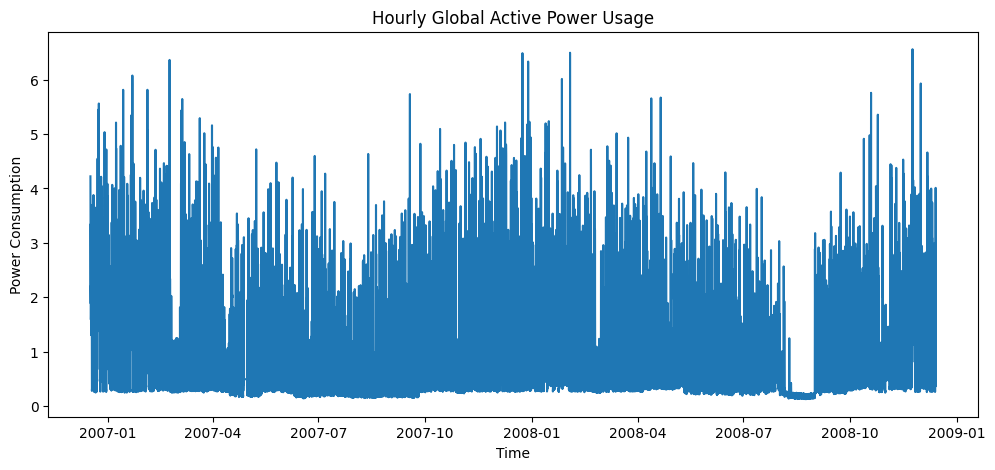

In [66]:
plt.figure(figsize=(12,5))
plt.plot(ts)
plt.title("Hourly Global Active Power Usage")
plt.xlabel("Time")
plt.ylabel("Power Consumption")
plt.show()

In [67]:
train_size = int(len(ts) * 0.8)

train = ts[:train_size]
test = ts[train_size:]

print(train.shape, test.shape)

(13981,) (3496,)


In [68]:
from statsmodels.tsa.arima.model import ARIMA

In [69]:
# ARIMA model (simple baseline)
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

                                SARIMAX Results                                
Dep. Variable:     Global_active_power   No. Observations:                13981
Model:                  ARIMA(5, 1, 0)   Log Likelihood              -15111.680
Date:                 Mon, 22 Jun 2026   AIC                          30235.360
Time:                         22:18:36   BIC                          30280.632
Sample:                     12-16-2006   HQIC                         30250.433
                          - 07-21-2008                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1023      0.006    -15.841      0.000      -0.115      -0.090
ar.L2         -0.1565      0.007    -21.714      0.000      -0.171      -0.142
ar.L3         -0.1237      0.008    -15.891 

In [70]:
predictions = model_fit.forecast(steps=len(test))

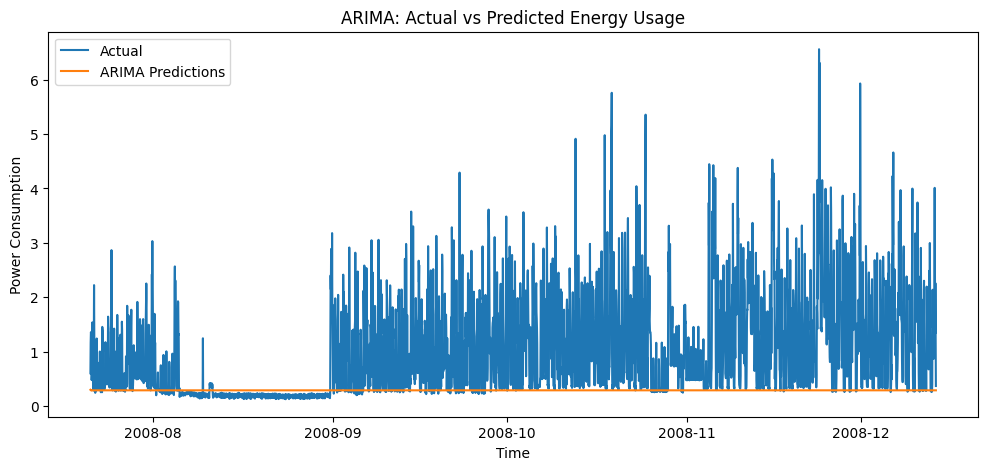

In [71]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test, label="Actual")
plt.plot(test.index, predictions, label="ARIMA Predictions")

plt.title("ARIMA: Actual vs Predicted Energy Usage")
plt.xlabel("Time")
plt.ylabel("Power Consumption")
plt.legend()

plt.show()

In [72]:
prophet_df = df['Global_active_power'].resample('h').mean().ffill().reset_index()

prophet_df.columns = ['ds', 'y']

prophet_df.head()

,ds,y
0,2006-12-16 17:00:00,4.222889
1,2006-12-16 18:00:00,3.632200
2,2006-12-16 19:00:00,3.400233
3,2006-12-16 20:00:00,3.268567
4,2006-12-16 21:00:00,3.056467


In [73]:
train_size = int(len(prophet_df) * 0.8)

train = prophet_df[:train_size]
test = prophet_df[train_size:]

In [74]:
from prophet import Prophet

model = Prophet()
model.fit(train)

22:18:41 - cmdstanpy - INFO - Chain [1] start processing
22:18:45 - cmdstanpy - INFO - Chain [1] done processing


In [75]:
future = model.make_future_dataframe(periods=len(test), freq='h')
forecast = model.predict(future)

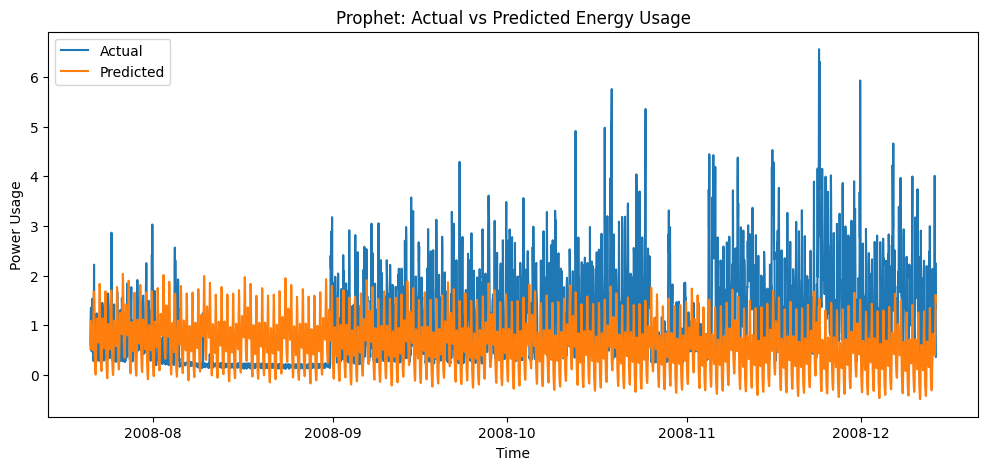

In [76]:
plt.figure(figsize=(12,5))

plt.plot(test['ds'], test['y'], label='Actual')
plt.plot(forecast['ds'].iloc[-len(test):], forecast['yhat'].iloc[-len(test):], label='Predicted')

plt.title("Prophet: Actual vs Predicted Energy Usage")
plt.xlabel("Time")
plt.ylabel("Power Usage")
plt.legend()

plt.show()

In [77]:
xgb_df = df['Global_active_power'].resample('h').mean().ffill().to_frame()

In [78]:
xgb_df['Hour'] = xgb_df.index.hour
xgb_df['Day'] = xgb_df.index.day
xgb_df['Month'] = xgb_df.index.month
xgb_df['DayOfWeek'] = xgb_df.index.dayofweek
xgb_df['Weekend'] = (xgb_df['DayOfWeek'] >= 5).astype(int)

In [79]:
xgb_df['Lag_1'] = xgb_df['Global_active_power'].shift(1)

# Drop missing values caused by lag
xgb_df.dropna(inplace=True)

In [80]:
X = xgb_df.drop('Global_active_power', axis=1)
y = xgb_df['Global_active_power']

In [81]:
split = int(len(xgb_df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [82]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [83]:
y_pred = model.predict(X_test)

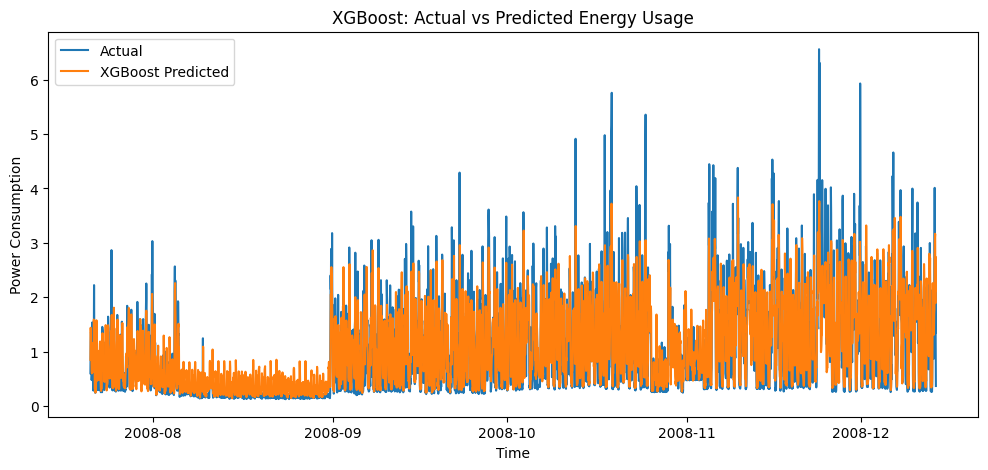

In [84]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, label='XGBoost Predicted')

plt.title("XGBoost: Actual vs Predicted Energy Usage")
plt.xlabel("Time")
plt.ylabel("Power Consumption")
plt.legend()

plt.show()

In [85]:
from sklearn.metrics import mean_squared_error
import numpy as np

In [88]:
from sklearn.metrics import mean_squared_error
import numpy as np

# use ONLY the target column (replace 'y' with your actual column name)
y_true = test["y"].values

# predictions must be numpy array
y_pred = np.array(predictions)

# RMSE calculation
arima_rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("ARIMA RMSE:", arima_rmse)

ARIMA RMSE: 1.1193486883267665


In [ ]:
prophet_pred = forecast['yhat'].iloc[-len(test):]

prophet_rmse = np.sqrt(mean_squared_error(test['y'], prophet_pred))
print("Prophet RMSE:", prophet_rmse)

In [ ]:
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("XGBoost RMSE:", xgb_rmse)

In [ ]:
results = pd.DataFrame({
    "Model": ["ARIMA", "Prophet", "XGBoost"],
    "RMSE": [arima_rmse, prophet_rmse, xgb_rmse]
})

results

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(x="Model", y="RMSE", data=results)

plt.title("Model Performance Comparison (Lower is Better)")
plt.show()

## Conclusion

In this project, short-term household energy consumption was forecasted using three different models: ARIMA, Prophet, and XGBoost. After preprocessing the time series data and engineering time-based features, each model was trained and evaluated using RMSE.

The results show that machine learning-based approaches (XGBoost) generally perform better in capturing complex nonlinear patterns compared to traditional statistical models like ARIMA. Prophet also performs well by handling seasonality and trends effectively. Overall, XGBoost achieved the best performance, making it the most suitable model for short-term energy forecasting in this dataset.